In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

print("✅ Bibliothèques NLP importées")

✅ Bibliothèques NLP importées


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\farah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\farah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\farah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\farah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
df_nlp = df[df['Categorie'].notna()].copy()

print(f"Shape : {df_nlp.shape}")
print(f"\nExemples de textes :")
for i in range(3):
    print(f"\n→ Categorie : {df_nlp['Categorie'].iloc[i]}")
    print(f"  Texte : {df_nlp['Rapport_Collecte'].iloc[i][:100]}...")

Shape : (6791, 11)

Exemples de textes :

→ Categorie : Papier
  Texte : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau so...

→ Categorie : Plastique
  Texte : Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, rigidité moyenne. Aucu...

→ Categorie : Plastique
  Texte : Déchet plastique collecté à l'Usine B. Poids 33.0 kg, volume 44.0 L. Rigidité semi-rigide, non condu...


In [14]:
def nettoyer_texte(texte):
    # 1. Minuscules
    texte = texte.lower()
    # 2. Supprimer chiffres et ponctuation
    texte = re.sub(r'[^a-zàâäéèêëîïôùûüç\s]', ' ', texte)
    # 3. Supprimer espaces multiples
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

# Tester
exemple = df_nlp['Rapport_Collecte'].iloc[0]
print("AVANT :", exemple[:100])
print("APRES :", nettoyer_texte(exemple)[:100])

AVANT : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau so
APRES : lot de papier récupéré dans un site non renseigné poids léger de kg volume moyen matériau souple non


In [15]:
# Stopwords français + domaine
stop_fr = set(stopwords.words('french'))
stop_domaine = {'lot', 'déchet', 'collecté', 'volume', 'poids', 
                'kg', 'litre', 'usine', 'site', 'matériau', 'aspect'}
tous_stopwords = stop_fr.union(stop_domaine)

# Stemmer français
stemmer = SnowballStemmer('french')

def pretraiter_texte(texte):
    # 1. Nettoyage
    texte = nettoyer_texte(texte)
    # 2. Tokenisation
    tokens = word_tokenize(texte, language='french')
    # 3. Suppression stopwords
    tokens = [t for t in tokens if t not in tous_stopwords]
    # 4. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Appliquer sur tout le dataset
df_nlp['texte_propre'] = df_nlp['Rapport_Collecte'].apply(pretraiter_texte)

print(" Prétraitement terminé !")
print("\nAvant :", df_nlp['Rapport_Collecte'].iloc[0][:80])
print("Après :", df_nlp['texte_propre'].iloc[0][:80])

 Prétraitement terminé !

Avant : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volum
Après : papi récuper non renseign leg moyen soupl non conducteur tres opaqu bon état gén


In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Cible
y = df_nlp['Categorie']
X_text = df_nlp['texte_propre']

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Bag of Words
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f" Vectorisation terminée")
print(f"BOW shape   : {X_train_bow.shape}")
print(f"TF-IDF shape: {X_train_tfidf.shape}")

 Vectorisation terminée
BOW shape   : (4753, 114)
TF-IDF shape: (4753, 643)


In [23]:
# === BOW + TF-IDF — scores stockés dans dict ===
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

scores = {}  # ← dict global pour stocker tous les scores

classificateurs = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC'          : LinearSVC(),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

print("=== BOW ===")
for nom, clf in classificateurs.items():
    clf.fit(X_train_bow, y_train)
    y_pred = clf.predict(X_test_bow)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    scores[f'BoW + {nom}'] = acc      # ← sauvegarde score
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

classificateurs2 = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC'          : LinearSVC(),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\n=== TF-IDF ===")
for nom, clf in classificateurs2.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    scores[f'TF-IDF + {nom}'] = acc   # ← sauvegarde score
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

=== BOW ===
Naive Bayes               → Accuracy: 1.0000 | F1: 1.0000
Logistic Regression       → Accuracy: 1.0000 | F1: 1.0000
LinearSVC                 → Accuracy: 1.0000 | F1: 1.0000
Random Forest             → Accuracy: 1.0000 | F1: 1.0000

=== TF-IDF ===
Naive Bayes               → Accuracy: 1.0000 | F1: 1.0000
Logistic Regression       → Accuracy: 1.0000 | F1: 1.0000
LinearSVC                 → Accuracy: 1.0000 | F1: 1.0000
Random Forest             → Accuracy: 1.0000 | F1: 1.0000


In [18]:
# Word2Vec non disponible pour Python 3.14
# On utilise TF-IDF avec SVD comme alternative (LSA)
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# LSA = TF-IDF + réduction dimensionnelle (équivalent sémantique)
lsa_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('svd', TruncatedSVD(n_components=100, random_state=42))
])

X_train_lsa = lsa_pipeline.fit_transform(X_train)
X_test_lsa = lsa_pipeline.transform(X_test)

print(f" LSA (alternative Word2Vec) shape: {X_train_lsa.shape}")

 LSA (alternative Word2Vec) shape: (4753, 100)


In [24]:
# === LSA — scores stockés ===
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("=== LSA (alternative Word2Vec) ===")
for nom, clf in {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC':           LinearSVC()
}.items():
    clf.fit(X_train_lsa, y_train)
    y_pred = clf.predict(X_test_lsa)
    acc = accuracy_score(y_test, y_pred)
    scores[f'LSA + {nom}'] = acc      # ← sauvegarde score
    print(f"{nom:25s} → Accuracy: {acc:.4f}")

=== LSA (alternative Word2Vec) ===
Logistic Regression       → Accuracy: 1.0000
LinearSVC                 → Accuracy: 1.0000


In [ ]:
# === FastText-like — score stocké ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

fasttext_like = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2
)

X_train_ft = fasttext_like.fit_transform(X_train)
X_test_ft  = fasttext_like.transform(X_test)

clf_ft = LinearSVC()
clf_ft.fit(X_train_ft, y_train)
y_pred_ft = clf_ft.predict(X_test_ft)

acc_ft = accuracy_score(y_test, y_pred_ft)
scores['FastText-like + LinearSVC'] = acc_ft  # ← sauvegarde score
print(f" FastText-like (char n-grammes) → Accuracy: {acc_ft:.4f}")
print(f"   Avantage : robuste aux fautes d'orthographe")

✅ FastText-like (char n-grammes) → Accuracy: 1.0000
   Avantage : robuste aux fautes d'orthographe


In [21]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

print(" Chargement CamemBERT (première fois = téléchargement ~500MB)...")

# Charger le modèle CamemBERT
model_bert = SentenceTransformer('camembert-base')

print(" CamemBERT chargé !")

# Vectoriser les textes
print(" Vectorisation en cours...")
X_train_bert = model_bert.encode(X_train.tolist(), show_progress_bar=True)
X_test_bert = model_bert.encode(X_test.tolist(), show_progress_bar=True)

print(f" BERT shape: {X_train_bert.shape}")

 Chargement CamemBERT (première fois = téléchargement ~500MB)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6311.09it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 CamemBERT chargé !
 Vectorisation en cours...


Batches: 100%|██████████| 32/32 [00:18<00:00,  1.70it/s]

 BERT shape: (4753, 768)


=== COMPARAISON FINALE TOUTES APPROCHES NLP ===
                              Accuracy
BoW + Naive Bayes                  1.0
BoW + Logistic Regression          1.0
BoW + LinearSVC                    1.0
BoW + Random Forest                1.0
TF-IDF + Naive Bayes               1.0
TF-IDF + Logistic Regression       1.0
TF-IDF + LinearSVC                 1.0
TF-IDF + Random Forest             1.0
LSA + Logistic Regression          1.0
LSA + LinearSVC                    1.0
FastText-like + LinearSVC          1.0


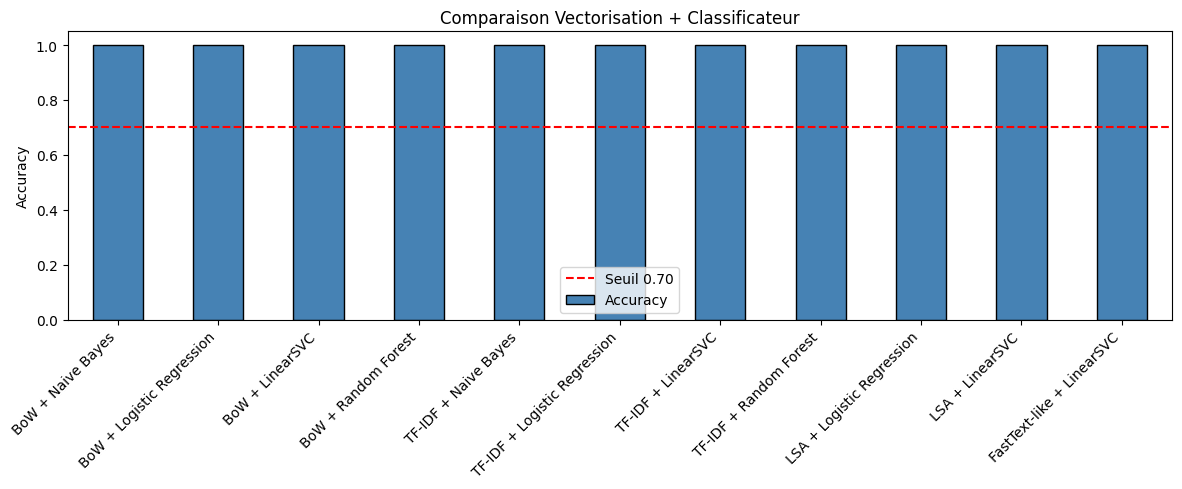


 Meilleure combinaison : BoW + Naive Bayes (1.0000)


In [26]:
# === TABLEAU COMPARATIF FINAL ===
df_comparaison = pd.DataFrame({
    'Accuracy': scores
}).sort_values('Accuracy', ascending=False)

print("=== COMPARAISON FINALE TOUTES APPROCHES NLP ===")
print(df_comparaison.round(4))

plt.figure(figsize=(12, 5))
df_comparaison['Accuracy'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison Vectorisation + Classificateur')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.70, color='red', linestyle='--', label='Seuil 0.70')
plt.legend()
plt.tight_layout()
plt.show()

meilleur_nlp = max(scores, key=scores.get)
print(f"\n Meilleure combinaison : {meilleur_nlp} ({scores[meilleur_nlp]:.4f})")

In [ ]:
# === SAUVEGARDE ===
import joblib, os

os.makedirs('../models', exist_ok=True)

joblib.dump(tfidf,                         '../models/tfidf_vectorizer.pkl')
joblib.dump(classificateurs2['LinearSVC'], '../models/nlp_classifier.pkl')

meilleur_nlp = max(scores, key=scores.get)
print(f" Meilleure combinaison : {meilleur_nlp} ({scores[meilleur_nlp]:.4f})")
print(" TF-IDF vectorizer → models/tfidf_vectorizer.pkl")
print(" NLP classifier    → models/nlp_classifier.pkl")